In [5]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"../main_code/2d/Ex4.4")
sys.path.append(r"../main_code/2d")
import generate_data2,grid_cell,adaptive_int_fix1,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main_fix1
CUDA_LAUNCH_BLOCKING=1

def single_S(y,x_left,x_right,y_below,y_upper,center,r): #单个源
    cond=(y[:,0]-center[0])**2+(y[:,1]-center[1])**2<=r**2
    return 0.5*np.exp(-550*((y[:,0]-center[0])**2+(y[:,1]-center[1])**2))*cond

def ana_S(y,x_left,x_right,y_below,y_upper,center,r): #总源
    cond1=(y[:,0]-center[0,0])**2+(y[:,1]-center[0,1])**2<=r**2
    cond2=(y[:,0]-center[1,0])**2+(y[:,1]-center[1,1])**2<=r**2
    return 0.5*np.exp(-550*((y[:,0]-center[0,0])**2+(y[:,1]-center[0,1])**2))*cond1+0.5*np.exp(-550*((y[:,0]-center[1,0])**2+(y[:,1]-center[1,1])**2))*cond2



cuda:1


In [6]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  #x方向网格点
nx,ny=3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=-0.3,0.3,-0.3,0.3
b_x_min,b_x_max,b_y_min,b_y_max=-0.35,0.35,-0.35,0.35 #边界gamma处

num_batches_gauss=1
b_n=20
points_b=mea_2D.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.06
center_true=np.array([[-0.06,0.0],[0.08,0.0]])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device=1

S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data2.boundary_data_circle(kk, number_gene, points_b, single_S,[],[],[],[],center_true[0],r_true,eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data2.boundary_data_circle(kk, number_gene, points_b, single_S, [],[],[],[],center_true[1], r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b0 = F_mea_b1 + F_mea_b2
F_mea_db_x10 = F_mea_db_x11 + F_mea_db_x12
F_mea_db_x20= F_mea_db_x21 + F_mea_db_x22
F=org_m.F(F_mea_b0,F_mea_db_x10,F_mea_db_x20)

cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
R_m=20
r_low,r_upper=0.18,0.2
b_below,b_upper=-0.51,-0.49


In [7]:
M=2400
af="Tanh"   #先用tanh
R_m=5
cupy_device= 1
models0 = net_2D_fix2.pre_define(Nx,Ny,M,R_m,"Tanh",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],device)

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


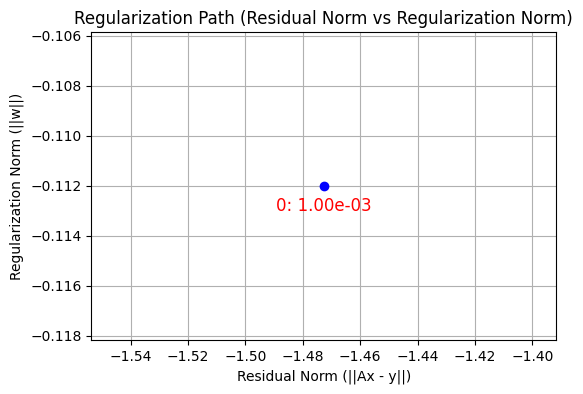

第 0 次迭代的train误差：
第 0 次迭代的泛化误差：


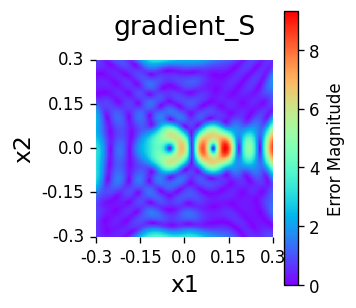

S_l_inf= 3.699321759596925 S_L_2= 0.03194610253668336 S_l_2= 0.5139286724388807


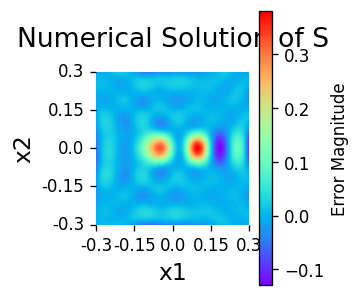

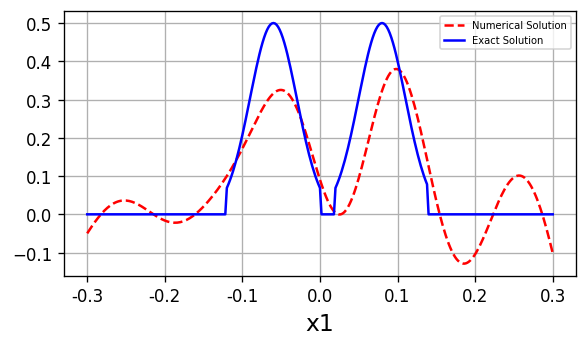

第 0 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


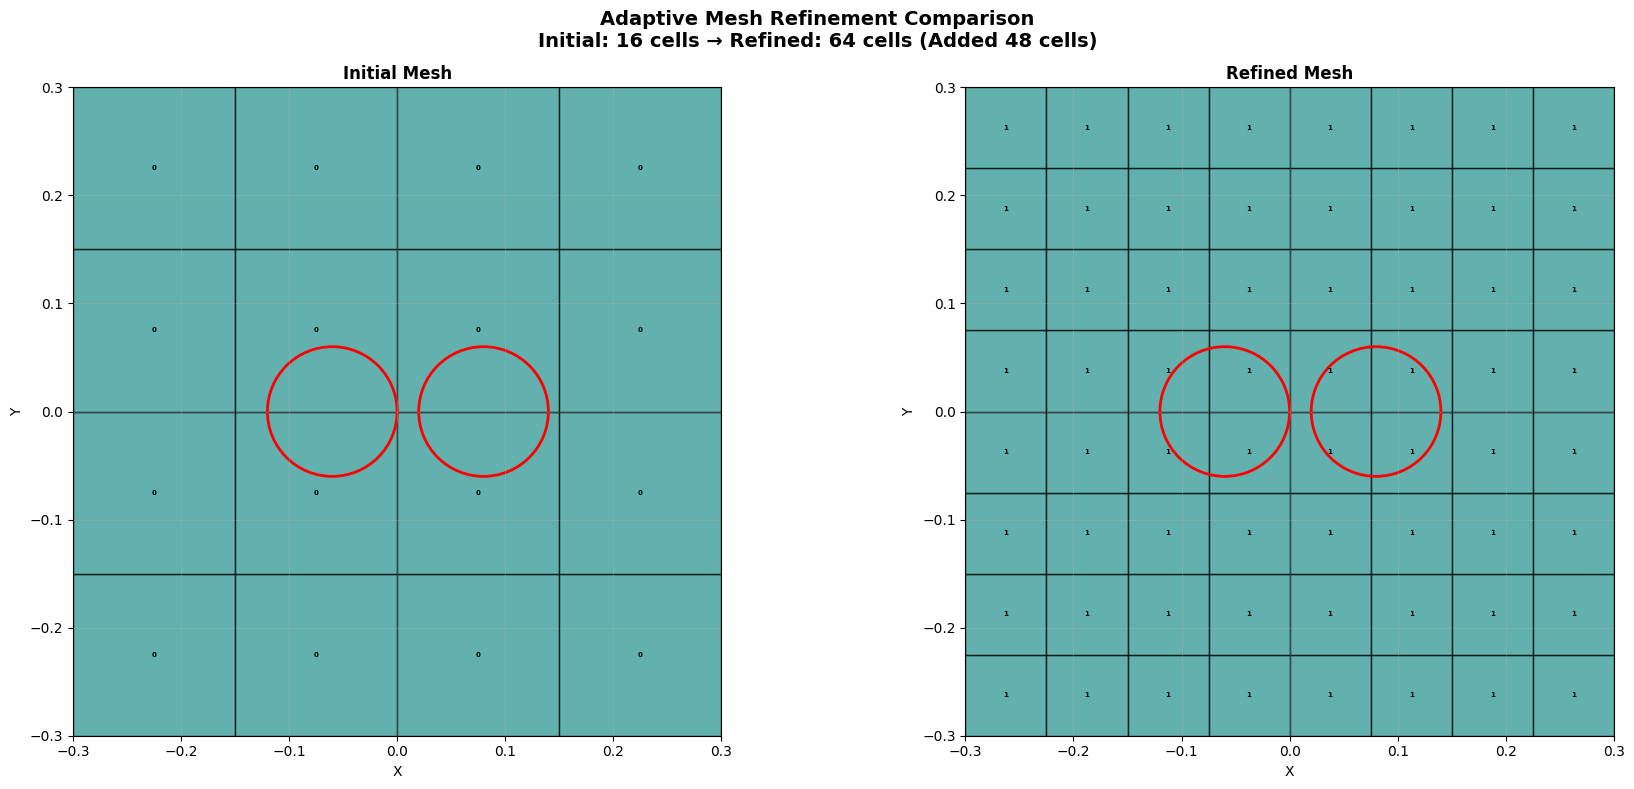

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


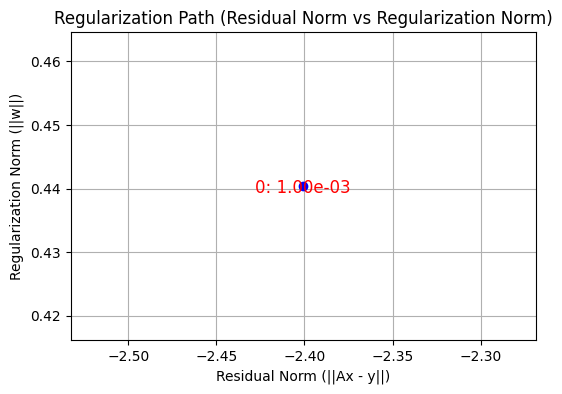

第 1 次迭代的train误差：
第 1 次迭代的泛化误差：


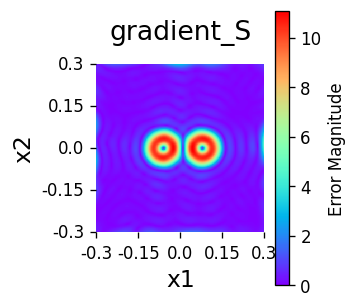

S_l_inf= 0.8479186044914105 S_L_2= 0.006366530417724399 S_l_2= 0.10242071069125622


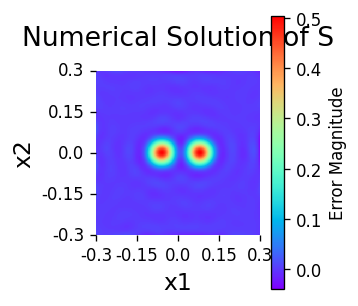

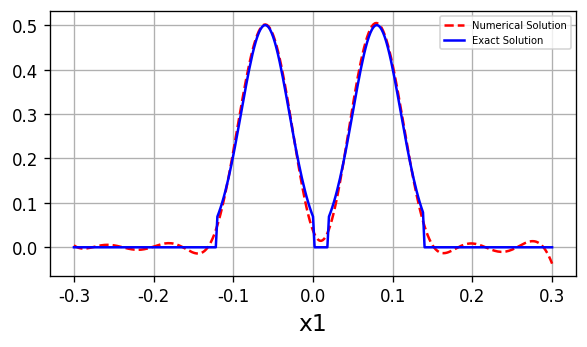

第 1 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


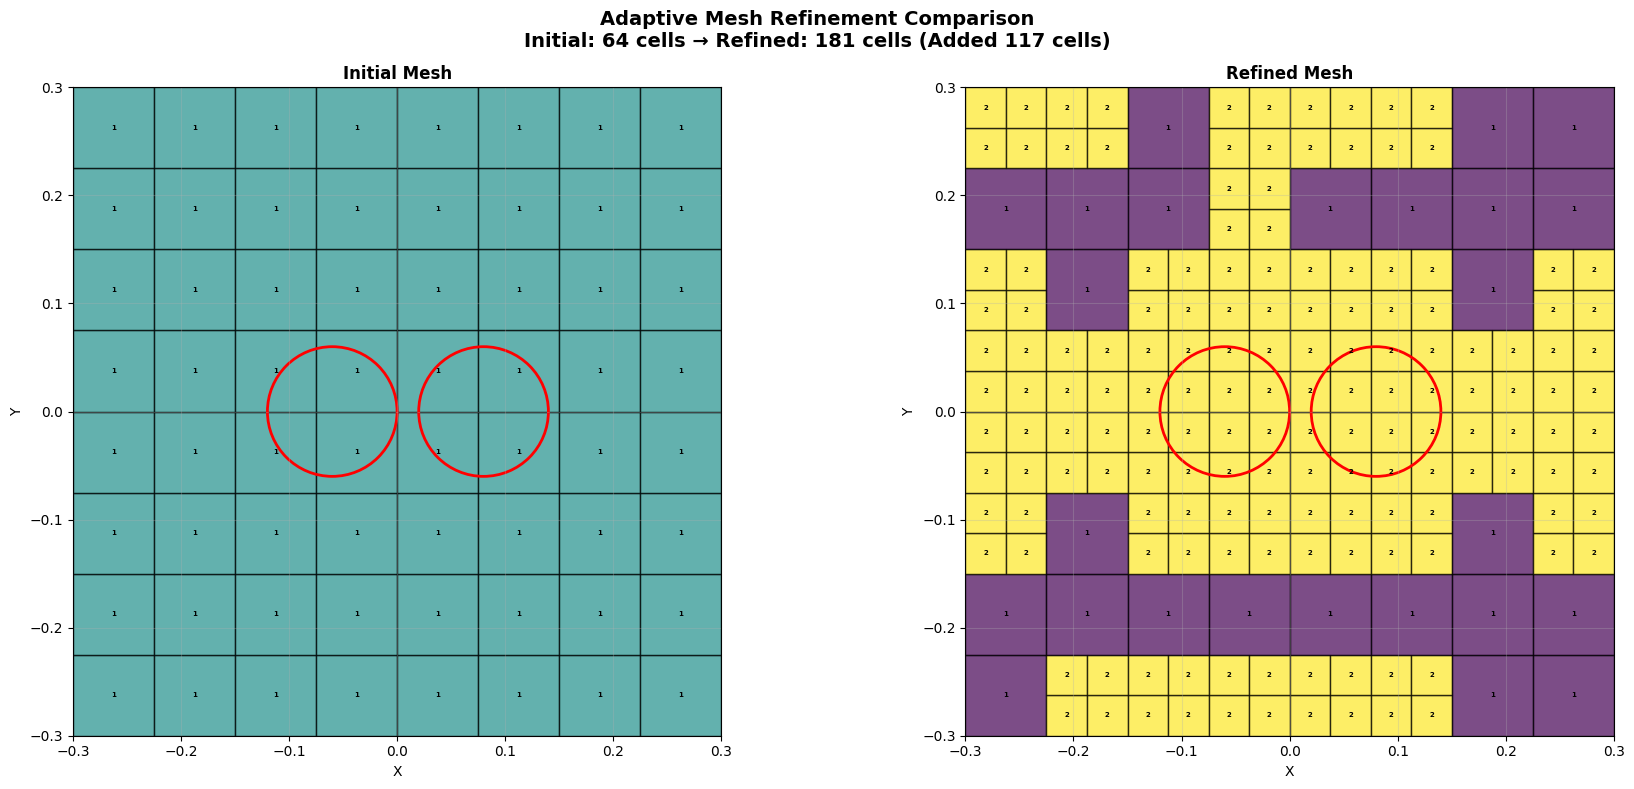

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


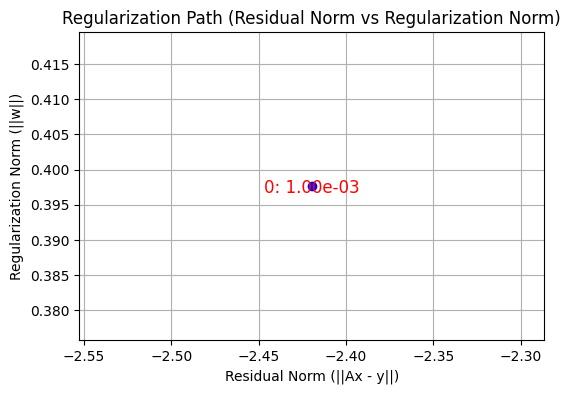

第 2 次迭代的train误差：
第 2 次迭代的泛化误差：


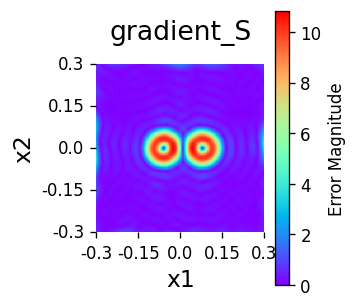

S_l_inf= 0.8999627889093957 S_L_2= 0.00610425156999395 S_l_2= 0.09820133463847708


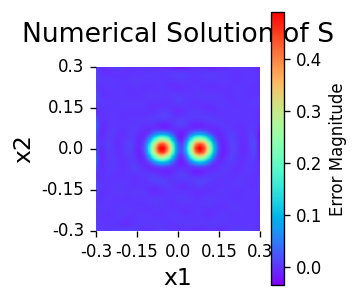

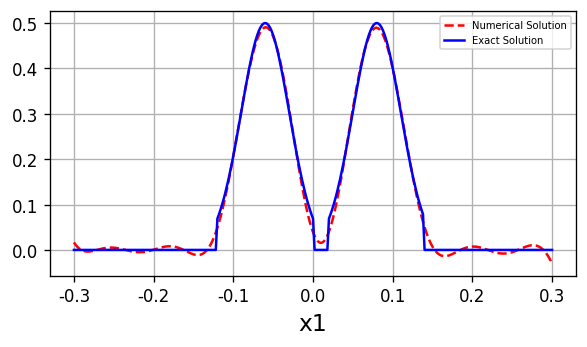

第 2 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


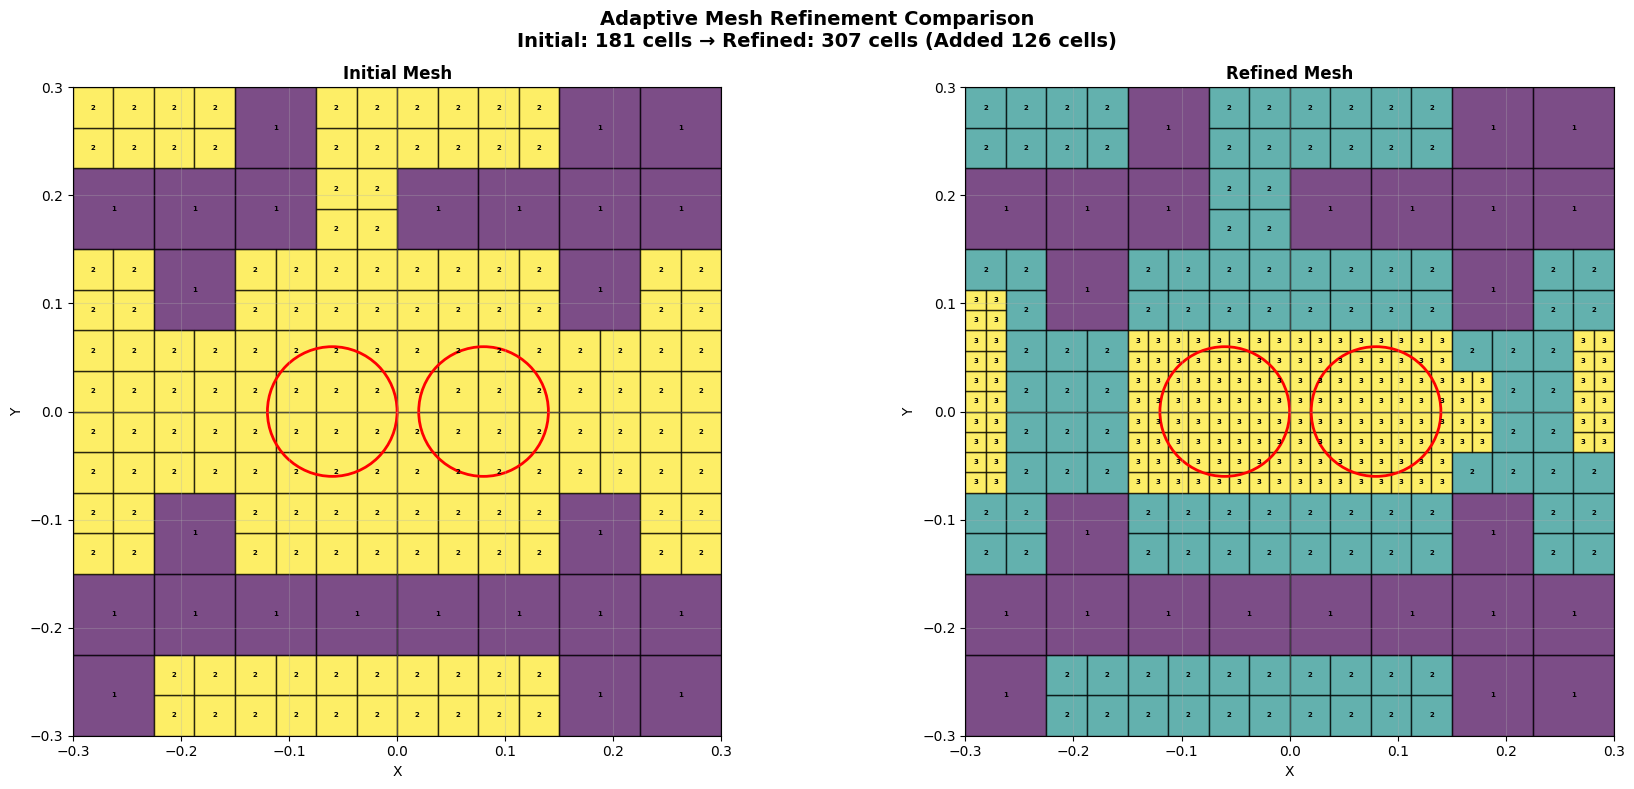

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


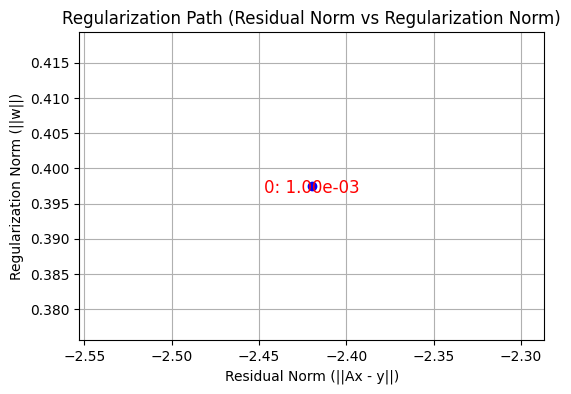

第 3 次迭代的train误差：
第 3 次迭代的泛化误差：


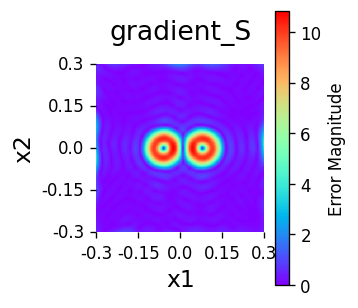

S_l_inf= 0.8999064925246045 S_L_2= 0.006105959002601441 S_l_2= 0.09822880273328578


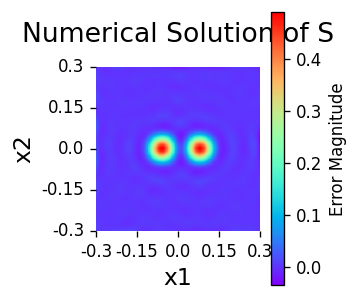

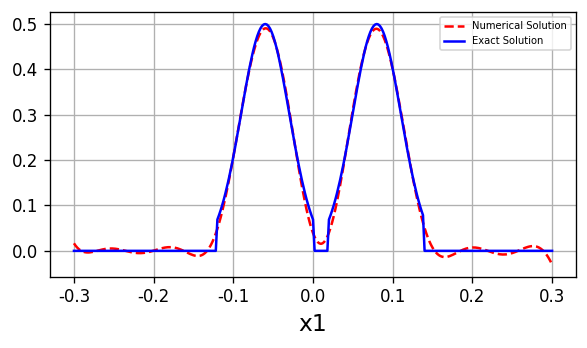

在第 3 次迭代结束


In [8]:
iter_int= 5
Ix,Iy=4,4  #x方向网格点
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-3,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
refine_threshold_S= [1/100] * 5
refine_threshold_grad=[1/1000000000] * 5
refine_threshold_noise=[1/300] * 5
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main_fix1.ada_int(iter_int,delta,cells,nx,models0,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)

In [9]:
np.save("./Noise/noise=10%/g_S.npy",g_S)
np.save("./Noise/noise=10%/S_num_store.npy",S_num_store)


Number of detected clusters: 2
Cluster 0: AR=1.02
  Res_Rect=0.078 vs Res_Ellip=0.070
  -> Winner: Circle
  CV of S_num: 0.742
Cluster 0: Lx=0.122, Ly=0.124, AR=1.02
  -> Decision: Circle (Exp)
  Center: (-0.061, -0.000)
    Radius: 0.065
    Rect Residual: 0.0782, Ellip Residual: 0.0700
    Aspect Ratio: 1.016
    Curvature - Std: 0.3677, Mean: 0.1439, Peak Ratio: 9.83
Cluster 1: AR=1.00
  Res_Rect=0.081 vs Res_Ellip=0.063
  -> Winner: Circle
  CV of S_num: 0.743
Cluster 1: Lx=0.124, Ly=0.124, AR=1.00
  -> Decision: Circle (Exp)
  Center: (0.081, 0.000)
    Radius: 0.065
    Rect Residual: 0.0812, Ellip Residual: 0.0632
    Aspect Ratio: 1.000
    Curvature - Std: 0.3677, Mean: 0.1439, Peak Ratio: 9.83


/mnt/store/hxw-y23/MA-RFM-GIT/Ex4.4/./main_code/Bound_detect.py:321: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


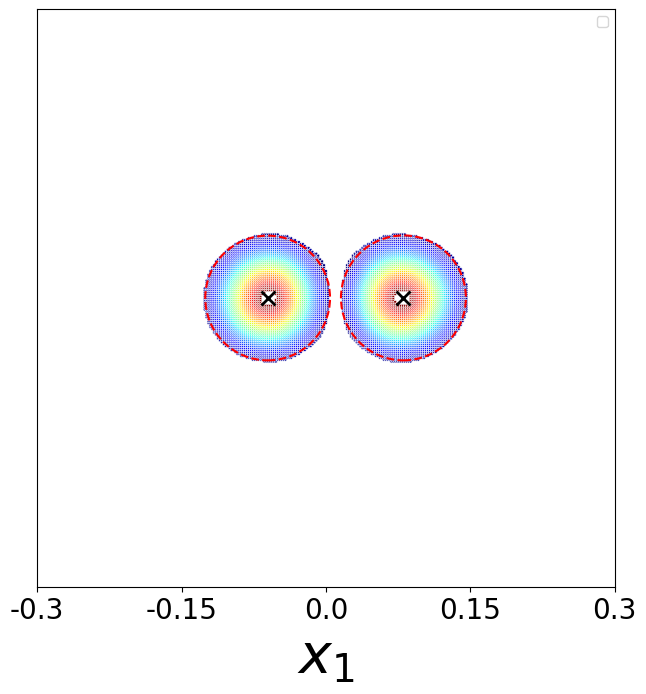

In [10]:
from importlib import reload
import Bound_detect
reload(Bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=0.01
mini_samples=10
para_abs=100
para_grad=3
results=Bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./Noise/noise=10%", output_filename="plot.png")

Number of detected clusters: 2
Cluster 0: AR=1.02
  Res_Rect=0.078 vs Res_Ellip=0.070
  -> Winner: Circle
  CV of S_num: 0.742
Cluster 0: Lx=0.122, Ly=0.124, AR=1.02
  -> Decision: Circle (Exp)
Cluster 1: AR=1.00
  Res_Rect=0.081 vs Res_Ellip=0.063
  -> Winner: Circle
  CV of S_num: 0.743
Cluster 1: Lx=0.124, Ly=0.124, AR=1.00
  -> Decision: Circle (Exp)


/mnt/store/hxw-y23/MA-RFM-GIT/Ex4.4/./main_code/bound_detect.py:314: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


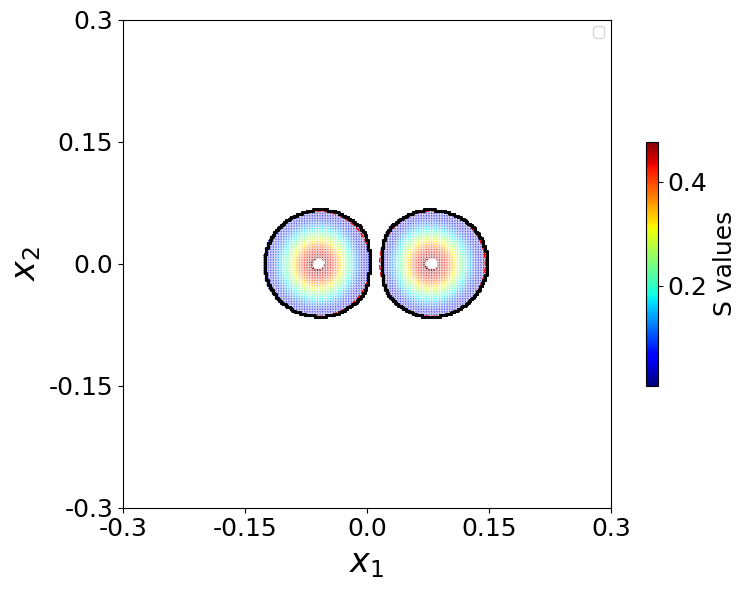

<Figure size 640x480 with 0 Axes>

In [11]:
from importlib import reload
import bound_detect
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=0.01
mini_samples=10
para_abs=100
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./Noise/noise=10%", output_filename="plot.png")

In [12]:
results

[{'cluster_id': 0,
  'shape': 'Circle',
  'params': {'center': array([-6.05644925e-02, -3.50979819e-05]),
   'radius': 0.06480216988441749},
  'profile': 'Exp'},
 {'cluster_id': 1,
  'shape': 'Circle',
  'params': {'center': array([8.05042311e-02, 9.39597315e-05]),
   'radius': 0.06489716397008362},
  'profile': 'Exp'}]

In [13]:
center1=results[0]['params']['center']
r1=results[0]['params']['radius']
center2=results[1]['params']['center']
r2=results[1]['params']['radius']

In [14]:
r1*(1+0.03)

0.06674623498095002

In [34]:
# k=1 r=0.2 R_m=0.3 K=1000 M=800*2
M0=2400
M1=2000
M2=2000
R_m=1 #w -0.6~0.6 b: -0.3-0.3
rangee1=[np.abs(center1[0])*0.05,np.abs(center1[1])*2]
rangee2=[np.abs(center2[0])*0.05,np.abs(center2[1])*2]
r_minl,r_maxl=r1*(1-0.1),r1*(1+0.03)
r_minr,r_maxr=r2*(1-0.1),r2*(1+0.03)
b1_minl,b1_maxl=-(center1[0]*(1-0.03)),-(center1[0]*(1+0.03))
b2_minl,b2_maxl=(center1[1]*(1+0.03)),-(center1[1]*(1+0.03))
b1_minr,b1_maxr=-(center2[0]*(1+0.03)),-(center2[0]*(1-0.03))
b2_minr,b2_maxr=-(center2[1]*(1+0.03)),(center2[1]*(1+0.03))
v_min,v_max=-1000,0
peak_min,peak_max=0.3,0.6
K_min,K_max=1000,20000
#models0 = net_2D_fix2.pre_define(Nx,Ny,M0,1,"Tanh",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_min,r_max,b1_min1,b1_max1,b2_min1,b2_max1,peak_min,peak_max,v_min,v_max,K_min,K_max,device)
models1 = net_2D_fix2.pre_define(Nx,Ny,M1,1,"Gauss",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_minl,r_maxl,b1_minl,b1_maxl,b2_minl,b2_maxl,peak_min,peak_max,v_min,v_max,K_min,K_max,device)
models2 = net_2D_fix2.pre_define(Nx,Ny,M2,1,"Gauss",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_minr,r_maxr,b1_minr,b1_maxr,b2_minr,b2_maxr,peak_min,peak_max,v_min,v_max,K_min,K_max,device)
af="mix"
sum_mat,all_g_p1,all_g_n,cells_copy1=cal_S_grad.mat_assemble2(cells_store[-1],models0,models1,models2,"mix",kk,0,points_b,device,cupy_device)


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


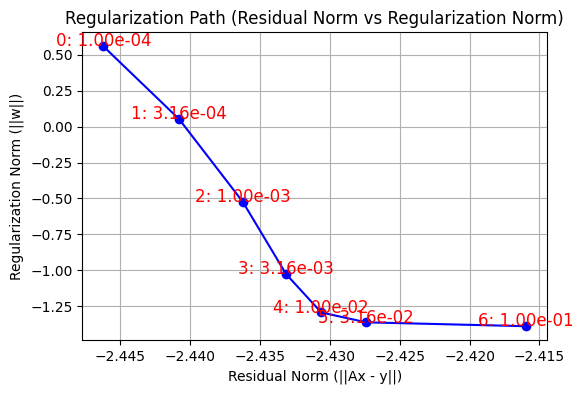

In [35]:
lamb_regu=np.logspace(-4,-1,7,endpoint=True)
res,reg_norm,w_store=org_m.L_curve(M0,M1,M2,af,sum_mat,F,lamb_regu,cupy_device) #先进行求解

lamb: 0.0001
S_l_inf= 0.7625255840139309 S_L_2= 0.0028497190125597945 S_l_2= 0.04584447530859089


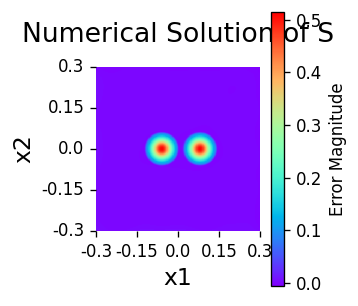

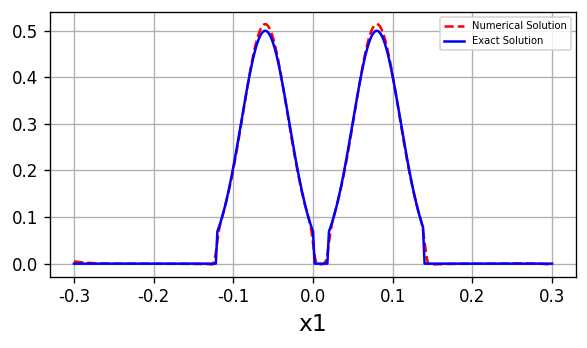

In [ ]:
lamb=lamb_regu[411]**2
print('lamb:', lamb)
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS=error_general_2D.test(models0,models1,models2,150,150,w_store[:,4],"mix",True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],center_true,r_true,ana_S,0,device)

In [37]:
# 保存 models1 模型
torch.save(models0,f"./Noise/noise=10%/models0_33_2400_{point_number[-1]}_{lamb}.pth")
torch.save(models1,f"./Noise/noise=10%/models1_33_2000_left.pth")
torch.save(models2,f"./Noise/noise=10%/models2_33_2000_right.pth")

In [38]:
np.save(f"./Noise/noise=10%/S_num_{lamb}",S_test_num)
np.save("./Noise/noise=10%/all_mat",sum_mat)
np.save("./Noise/noise=10%/w_store",w_store)
np.save("./Noise/noise=10%/F_mea_b",F_mea_b0)
np.save("./Noise/noise=10%/F_mea_db_x1",F_mea_db_x10)
np.save("./Noise/noise=10%/F_mea_db_x2",F_mea_db_x20)
np.save("./Noise/noise=10%/F",F)

In [39]:
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('center1[0]:',center1)
print('center2[1]:',center2)
print('r1:',r1)
print('r2:',r2)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)

n_integral: 2763
center1[0]: [-6.05644925e-02 -3.50979819e-05]
center2[1]: [8.05042311e-02 9.39597315e-05]
r1: 0.06480216988441749
r2: 0.06489716397008362
S_l2[-1]: 0.09822880273328578
lamb_regu: 0.0001
S_l21: 0.04584447530859089
